  STEP 1: Loading Dataset

✓ Dataset loaded successfully!
  Rows    : 891
  Columns : 12

Column names:
  ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

First 5 rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   

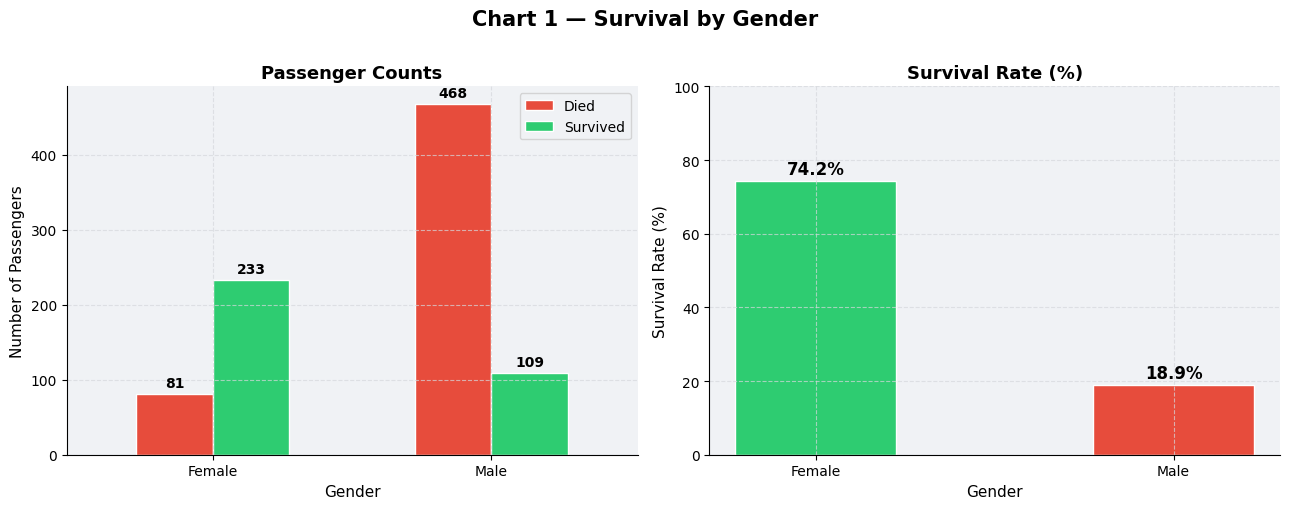


  ✓ Saved: titanic_outputs/chart1_survival_by_gender.png


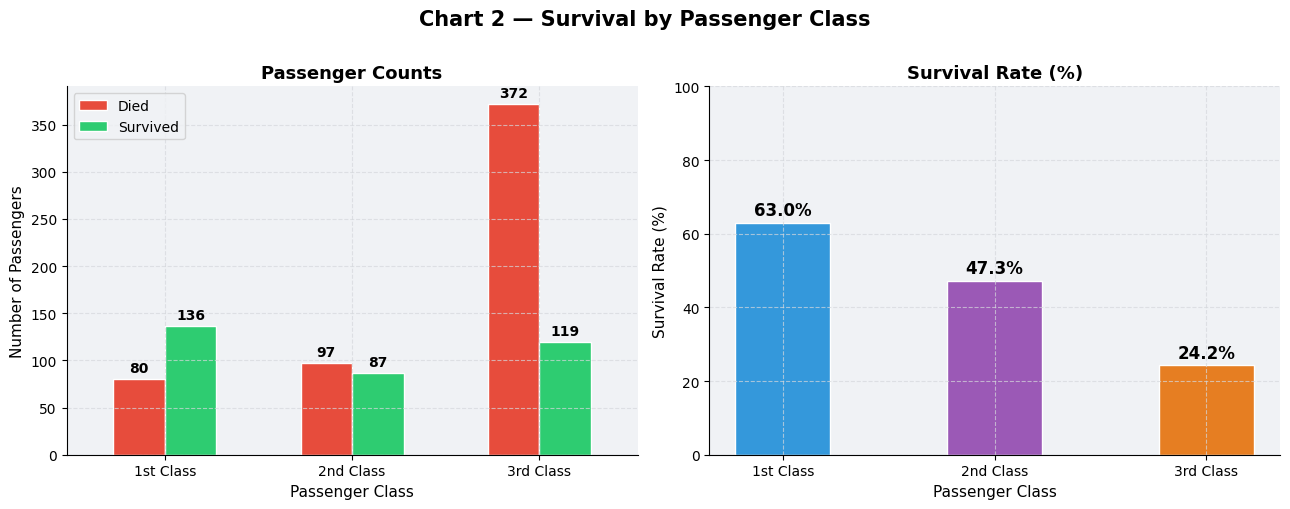

  ✓ Saved: titanic_outputs/chart2_survival_by_class.png


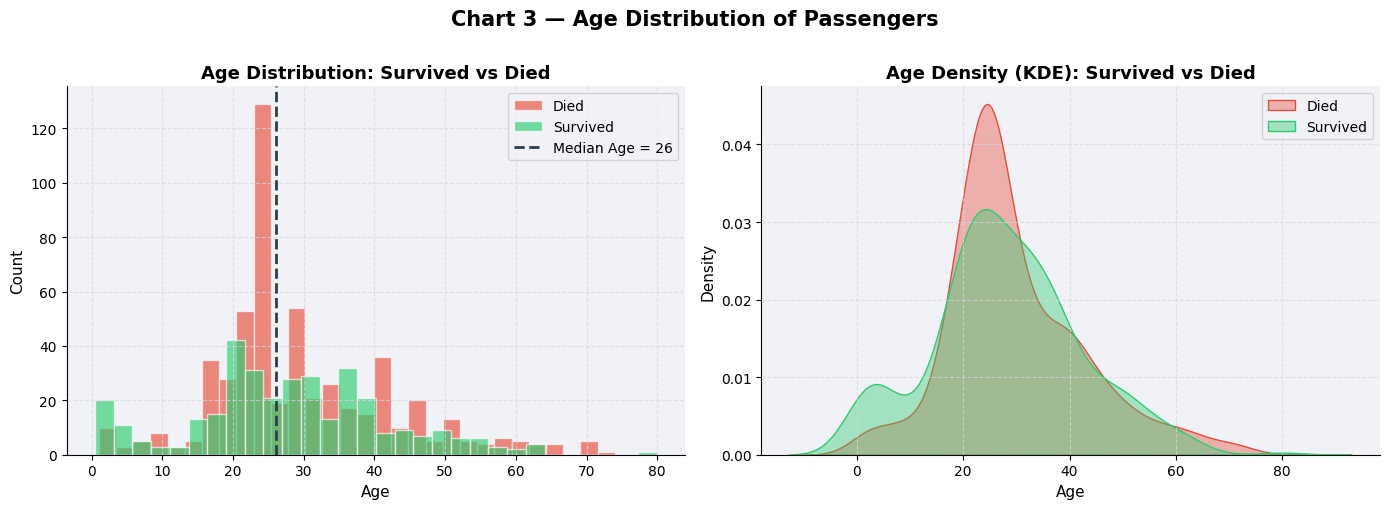

  ✓ Saved: titanic_outputs/chart3_age_histogram.png


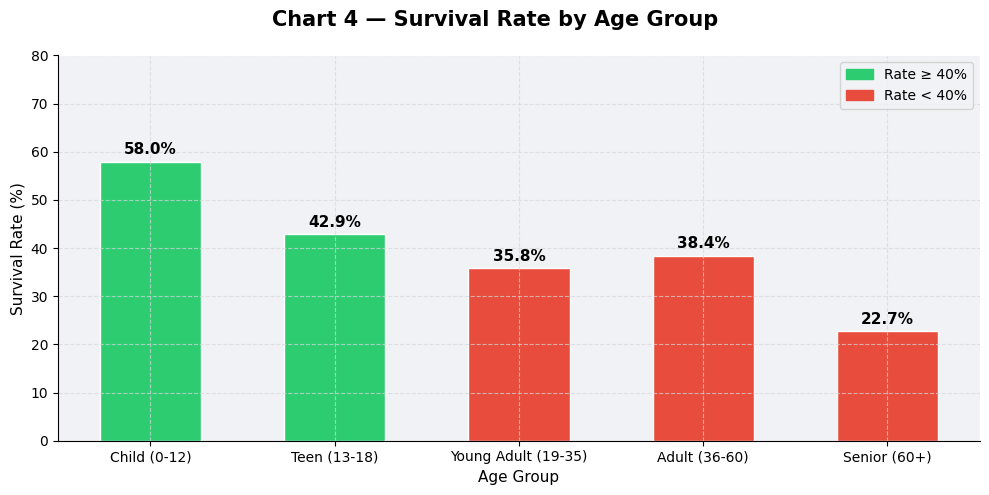

  ✓ Saved: titanic_outputs/chart4_survival_by_age_group.png


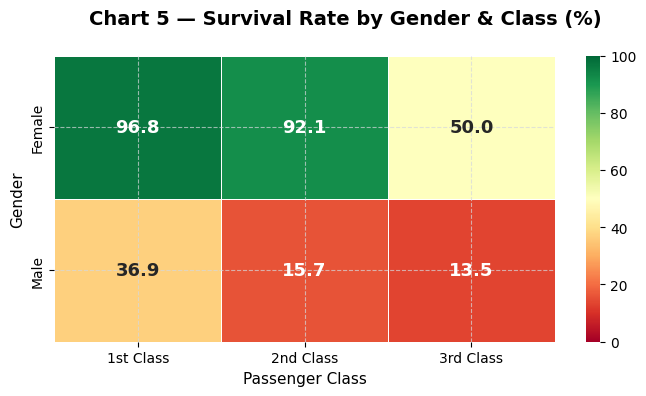

  ✓ Saved: titanic_outputs/chart5_heatmap_gender_class.png

  STEP 6: Summary Report

  Dataset    : 891 passengers, 14 features
  Survivors  : 342 (38.4%)

  ┌─────────────────────────────────────────────────────┐
  │  Q1 – Survival by Gender                           │
  │  Female : 74.2%    Male : 18.9%               │
  │  → Women were 3.9x more likely to survive     │
  ├─────────────────────────────────────────────────────┤
  │  Q2 – Survival by Class                            │
  │  1st : 63.0%   2nd : 47.3%   3rd : 24.2%    │
  │  → Higher class = much better survival odds         │
  ├─────────────────────────────────────────────────────┤
  │  Q3 – Survival by Age Group                        │
  │  Best  : Child (0-12) (58.0%)        │
  │  Worst : Senior (60+) (22.7%)             │
  │  → Children had best odds; Seniors had worst        │
  └─────────────────────────────────────────────────────┘

  Charts saved in: ./titanic_outputs/
    • chart1_survival_by_gender.png
    

In [ ]:
# =============================================================================
#  Data Science with Python Internship – Task 2
#  Titanic Dataset: Survival Pattern Analysis & Visualization
# =============================================================================
#
#  REQUIREMENTS:
#    pip install pandas matplotlib seaborn numpy
#
#  DATASET:
#    Place 'Titanic-Dataset.csv' in the same folder as this script,
#    OR update the CSV_PATH variable below.
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────────────────────────────────────
# CONFIGURATION
# ─────────────────────────────────────────────────────────────────────────────

CSV_PATH   = 'Titanic-Dataset.csv'   # ← Change path if needed
OUTPUT_DIR = 'titanic_outputs'       # Charts will be saved here
os.makedirs(OUTPUT_DIR, exist_ok=True)


# ─────────────────────────────────────────────────────────────────────────────
# STEP 1 – LOAD DATASET
# ─────────────────────────────────────────────────────────────────────────────

print("=" * 60)
print("  STEP 1: Loading Dataset")
print("=" * 60)

df = pd.read_csv(CSV_PATH)

print(f"\n✓ Dataset loaded successfully!")
print(f"  Rows    : {df.shape[0]}")
print(f"  Columns : {df.shape[1]}")
print(f"\nColumn names:\n  {list(df.columns)}")
print(f"\nFirst 5 rows:\n{df.head()}")
print(f"\nData types:\n{df.dtypes}")


# ─────────────────────────────────────────────────────────────────────────────
# STEP 2 – DATA CLEANING (Handle Missing Values)
# ─────────────────────────────────────────────────────────────────────────────

print("\n" + "=" * 60)
print("  STEP 2: Data Cleaning")
print("=" * 60)

print(f"\nMissing values BEFORE cleaning:")
print(df.isnull().sum().to_string())

# --- Age: Fill with median grouped by Pclass + Sex ---
# (More accurate than a single global median)
df['Age'] = df.groupby(['Pclass', 'Sex'])['Age'].transform(
    lambda x: x.fillna(x.median())
)

# --- Embarked: Fill with mode (most frequent port) ---
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# --- Cabin: Too many missing – label as 'Unknown' ---
df['Cabin'] = df['Cabin'].fillna('Unknown')

print(f"\nMissing values AFTER cleaning:")
print(df.isnull().sum().to_string())
print(f"\n✓ Cleaning complete!")
print(f"  • Age    → filled using median grouped by Pclass & Sex")
print(f"  • Embarked → filled with mode ('{df['Embarked'].mode()[0]}')")
print(f"  • Cabin  → labelled 'Unknown'")


# ─────────────────────────────────────────────────────────────────────────────
# STEP 3 – FEATURE ENGINEERING
# ─────────────────────────────────────────────────────────────────────────────

# Create Age Groups
age_bins   = [0, 12, 18, 35, 60, 100]
age_labels = ['Child (0-12)', 'Teen (13-18)', 'Young Adult (19-35)',
              'Adult (36-60)', 'Senior (60+)']
df['AgeGroup'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels)

# Fare group
df['FareGroup'] = pd.cut(df['Fare'],
                         bins=[0, 10, 30, 100, 600],
                         labels=['Low', 'Medium', 'High', 'Very High'])

print(f"\n✓ New features created: 'AgeGroup', 'FareGroup'")


# ─────────────────────────────────────────────────────────────────────────────
# STEP 4 – ANALYSIS: Answer the 3 Key Questions
# ─────────────────────────────────────────────────────────────────────────────

print("\n" + "=" * 60)
print("  STEP 4: Analysis & Key Questions")
print("=" * 60)

overall_rate = df['Survived'].mean() * 100
print(f"\n  Overall Survival Rate: {overall_rate:.1f}%  "
      f"({df['Survived'].sum()} / {len(df)} passengers)")

# ── Q1: Who survived more – males or females? ──────────────────────────────
print("\n" + "-" * 50)
print("  Q1: Who survived more – Males or Females?")
print("-" * 50)

gender_stats = df.groupby('Sex')['Survived'].agg(
    Survived='sum',
    Total='count'
).assign(SurvivalRate=lambda x: (x['Survived'] / x['Total'] * 100).round(2))

print(gender_stats.to_string())

female_rate = gender_stats.loc['female', 'SurvivalRate']
male_rate   = gender_stats.loc['male',   'SurvivalRate']
print(f"\n  ➤ Females survived at {female_rate:.1f}% vs Males at {male_rate:.1f}%")
print(f"  ➤ Females were {female_rate/male_rate:.1f}x more likely to survive!")

# ── Q2: Did passenger class affect survival? ──────────────────────────────
print("\n" + "-" * 50)
print("  Q2: Did Passenger Class Affect Survival Chances?")
print("-" * 50)

class_stats = df.groupby('Pclass')['Survived'].agg(
    Survived='sum',
    Total='count'
).assign(SurvivalRate=lambda x: (x['Survived'] / x['Total'] * 100).round(2))
class_stats.index = ['1st Class', '2nd Class', '3rd Class']

print(class_stats.to_string())
print(f"\n  ➤ Yes! 1st class: {class_stats.iloc[0]['SurvivalRate']:.1f}%  "
      f"vs 3rd class: {class_stats.iloc[2]['SurvivalRate']:.1f}%")
print(f"  ➤ Higher class = significantly better survival odds.")

# ── Q3: Survival rate by age group ────────────────────────────────────────
print("\n" + "-" * 50)
print("  Q3: What was the Survival Rate by Age Group?")
print("-" * 50)

age_stats = df.groupby('AgeGroup', observed=True)['Survived'].agg(
    Survived='sum',
    Total='count'
).assign(SurvivalRate=lambda x: (x['Survived'] / x['Total'] * 100).round(2))

print(age_stats.to_string())
best_group  = age_stats['SurvivalRate'].idxmax()
worst_group = age_stats['SurvivalRate'].idxmin()
print(f"\n  ➤ Best  survival: {best_group}  ({age_stats.loc[best_group,'SurvivalRate']:.1f}%)")
print(f"  ➤ Worst survival: {worst_group} ({age_stats.loc[worst_group,'SurvivalRate']:.1f}%)")


# ─────────────────────────────────────────────────────────────────────────────
# STEP 5 – VISUALIZATION
# ─────────────────────────────────────────────────────────────────────────────

print("\n" + "=" * 60)
print("  STEP 5: Generating Visualizations")
print("=" * 60)

# ── Global Style ──────────────────────────────────────────────────────────
SURVIVED_COLOR = '#2ECC71'
DIED_COLOR     = '#E74C3C'
CLASS_COLORS   = ['#3498DB', '#9B59B6', '#E67E22']
BG             = '#F0F2F5'
GRID_COLOR     = '#D5D8DC'

plt.rcParams.update({
    'font.family':       'DejaVu Sans',
    'axes.facecolor':    BG,
    'figure.facecolor':  'white',
    'axes.grid':         True,
    'grid.color':        GRID_COLOR,
    'grid.linestyle':    '--',
    'grid.alpha':        0.7,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.labelsize':    11,
    'axes.titlesize':    13,
    'axes.titleweight':  'bold',
})

# ═══════════════════════════════════════════════════════════════════════════
# CHART 1: Bar chart – Survival by Gender
# ═══════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Chart 1 — Survival by Gender', fontsize=15, fontweight='bold', y=1.01)

colors = [DIED_COLOR, SURVIVED_COLOR]
gender_counts = df.groupby(['Sex', 'Survived']).size().unstack(fill_value=0)
gender_counts.columns = ['Died', 'Survived']
gender_counts.index   = ['Female', 'Male']

# Counts
gender_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='white',
                   width=0.55, rot=0)
axes[0].set_title('Passenger Counts')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Number of Passengers')
for container in axes[0].containers:
    axes[0].bar_label(container, fontsize=10, fontweight='bold', padding=3)
axes[0].legend(['Died', 'Survived'])

# Survival Rate
rate_colors = [SURVIVED_COLOR, DIED_COLOR]
bars = axes[1].bar(['Female', 'Male'],
                   [female_rate, male_rate],
                   color=rate_colors, edgecolor='white', width=0.45)
axes[1].set_title('Survival Rate (%)')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Survival Rate (%)')
axes[1].set_ylim(0, 100)
for bar, val in zip(bars, [female_rate, male_rate]):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 2, f'{val:.1f}%',
                 ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
path1 = os.path.join(OUTPUT_DIR, 'chart1_survival_by_gender.png')
plt.savefig(path1, dpi=150, bbox_inches='tight')
plt.show()
print(f"\n  ✓ Saved: {path1}")


# ═══════════════════════════════════════════════════════════════════════════
# CHART 2: Bar chart – Survival by Passenger Class
# ═══════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Chart 2 — Survival by Passenger Class', fontsize=15,
             fontweight='bold', y=1.01)

class_counts = df.groupby(['Pclass', 'Survived']).size().unstack(fill_value=0)
class_counts.columns = ['Died', 'Survived']
class_counts.index   = ['1st Class', '2nd Class', '3rd Class']

class_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='white',
                  width=0.55, rot=0)
axes[0].set_title('Passenger Counts')
axes[0].set_xlabel('Passenger Class')
axes[0].set_ylabel('Number of Passengers')
for container in axes[0].containers:
    axes[0].bar_label(container, fontsize=10, fontweight='bold', padding=3)
axes[0].legend(['Died', 'Survived'])

rates = class_stats['SurvivalRate'].values
bars2 = axes[1].bar(['1st Class', '2nd Class', '3rd Class'],
                    rates, color=CLASS_COLORS, edgecolor='white', width=0.45)
axes[1].set_title('Survival Rate (%)')
axes[1].set_xlabel('Passenger Class')
axes[1].set_ylabel('Survival Rate (%)')
axes[1].set_ylim(0, 100)
for bar, val in zip(bars2, rates):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 2, f'{val:.1f}%',
                 ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
path2 = os.path.join(OUTPUT_DIR, 'chart2_survival_by_class.png')
plt.savefig(path2, dpi=150, bbox_inches='tight')
plt.show()
print(f"  ✓ Saved: {path2}")


# ═══════════════════════════════════════════════════════════════════════════
# CHART 3: Histogram – Passenger Ages
# ═══════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Chart 3 — Age Distribution of Passengers', fontsize=15,
             fontweight='bold', y=1.01)

survived_ages = df[df['Survived'] == 1]['Age'].dropna()
died_ages     = df[df['Survived'] == 0]['Age'].dropna()

# Overlapping histograms
axes[0].hist(died_ages,     bins=30, alpha=0.65, color=DIED_COLOR,
             label='Died',     edgecolor='white')
axes[0].hist(survived_ages, bins=30, alpha=0.65, color=SURVIVED_COLOR,
             label='Survived', edgecolor='white')
axes[0].axvline(df['Age'].median(), color='#2C3E50', linestyle='--',
                linewidth=2, label=f"Median Age = {df['Age'].median():.0f}")
axes[0].set_title('Age Distribution: Survived vs Died')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].legend()

# Seaborn KDE plot
sns.kdeplot(data=died_ages,     ax=axes[1], fill=True, alpha=0.4,
            color=DIED_COLOR,     label='Died')
sns.kdeplot(data=survived_ages, ax=axes[1], fill=True, alpha=0.4,
            color=SURVIVED_COLOR, label='Survived')
axes[1].set_title('Age Density (KDE): Survived vs Died')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
path3 = os.path.join(OUTPUT_DIR, 'chart3_age_histogram.png')
plt.savefig(path3, dpi=150, bbox_inches='tight')
plt.show()
print(f"  ✓ Saved: {path3}")


# ═══════════════════════════════════════════════════════════════════════════
# CHART 4 (Bonus): Survival Rate by Age Group
# ═══════════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('Chart 4 — Survival Rate by Age Group', fontsize=15,
             fontweight='bold')

age_rates  = age_stats['SurvivalRate'].values
age_groups = age_stats.index.astype(str)
bar_colors = [SURVIVED_COLOR if r >= 40 else DIED_COLOR for r in age_rates]

bars3 = ax.bar(age_groups, age_rates, color=bar_colors, edgecolor='white', width=0.55)
ax.set_xlabel('Age Group')
ax.set_ylabel('Survival Rate (%)')
ax.set_ylim(0, 80)
for bar, val in zip(bars3, age_rates):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1.5, f'{val:.1f}%',
            ha='center', fontsize=11, fontweight='bold')

survived_patch = mpatches.Patch(color=SURVIVED_COLOR, label='Rate ≥ 40%')
died_patch     = mpatches.Patch(color=DIED_COLOR,     label='Rate < 40%')
ax.legend(handles=[survived_patch, died_patch])

plt.tight_layout()
path4 = os.path.join(OUTPUT_DIR, 'chart4_survival_by_age_group.png')
plt.savefig(path4, dpi=150, bbox_inches='tight')
plt.show()
print(f"  ✓ Saved: {path4}")


# ═══════════════════════════════════════════════════════════════════════════
# CHART 5 (Bonus): Heatmap – Survival Rate by Gender & Class
# ═══════════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(7, 4))
fig.suptitle('Chart 5 — Survival Rate by Gender & Class (%)',
             fontsize=14, fontweight='bold')

pivot = df.pivot_table(values='Survived', index='Sex',
                       columns='Pclass', aggfunc='mean') * 100
pivot.index   = ['Female', 'Male']
pivot.columns = ['1st Class', '2nd Class', '3rd Class']

sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn',
            linewidths=0.5, ax=ax, vmin=0, vmax=100,
            annot_kws={'size': 13, 'weight': 'bold'})
ax.set_xlabel('Passenger Class')
ax.set_ylabel('Gender')

plt.tight_layout()
path5 = os.path.join(OUTPUT_DIR, 'chart5_heatmap_gender_class.png')
plt.savefig(path5, dpi=150, bbox_inches='tight')
plt.show()
print(f"  ✓ Saved: {path5}")


# ─────────────────────────────────────────────────────────────────────────────
# STEP 6 – SUMMARY REPORT
# ─────────────────────────────────────────────────────────────────────────────

print("\n" + "=" * 60)
print("  STEP 6: Summary Report")
print("=" * 60)

print(f"""
  Dataset    : {len(df)} passengers, {df.shape[1]} features
  Survivors  : {df['Survived'].sum()} ({overall_rate:.1f}%)

  ┌─────────────────────────────────────────────────────┐
  │  Q1 – Survival by Gender                           │
  │  Female : {female_rate:.1f}%    Male : {male_rate:.1f}%               │
  │  → Women were {female_rate/male_rate:.1f}x more likely to survive     │
  ├─────────────────────────────────────────────────────┤
  │  Q2 – Survival by Class                            │
  │  1st : {class_stats.iloc[0]['SurvivalRate']:.1f}%   2nd : {class_stats.iloc[1]['SurvivalRate']:.1f}%   3rd : {class_stats.iloc[2]['SurvivalRate']:.1f}%    │
  │  → Higher class = much better survival odds         │
  ├─────────────────────────────────────────────────────┤
  │  Q3 – Survival by Age Group                        │
  │  Best  : {best_group} ({age_stats.loc[best_group,'SurvivalRate']:.1f}%)        │
  │  Worst : {worst_group} ({age_stats.loc[worst_group,'SurvivalRate']:.1f}%)             │
  │  → Children had best odds; Seniors had worst        │
  └─────────────────────────────────────────────────────┘

  Charts saved in: ./{OUTPUT_DIR}/
    • chart1_survival_by_gender.png
    • chart2_survival_by_class.png
    • chart3_age_histogram.png
    • chart4_survival_by_age_group.png   (bonus)
    • chart5_heatmap_gender_class.png    (bonus)
""")

print("  ✅ Task 2 Complete!")
print("=" * 60)